## PART 1: PANDAS ESSENTIALS

In [9]:
import pandas as pd
import numpy as np

print("=" * 60)
print("PART 1: PANDAS BASICS")
print("=" * 60)

# Create a sample dataset
data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank', 'Grace', 'Henry'],
    'Age': [25, 30, 35, None, 28, 45, 32, 29],
    'City': ['NYC', 'LA', 'Chicago', 'NYC', 'LA', 'Chicago', 'NYC', 'LA'],
    'Salary': [50000, 60000, 75000, 55000, None, 90000, 62000, 58000],
    'Experience': [2, 5, 10, 3, 4, 20, 6, 5]
}

df = pd.DataFrame(data)

# 1. Basic exploration
print("\n1. First look at data:")
print(df.head())

print("\n2. Data information:")
print(df.info())

print("\n3. Statistical summary:")
print(df.describe())

# 2. Selecting data
print("\n4. Select single column:")
print(df['Age'].head())

print("\n5. Select multiple columns:")
print(df[['Name', 'Salary']].head())

# 3. Filtering rows
print("\n6. Filter rows where Age > 30:")
print(df[df['Age'] > 30])

print("\n7. Filter with multiple conditions:")
print(df[(df['Age'] > 25) & (df['City'] == 'NYC')])

# 4. Handling missing values
print("\n8. Check for missing values:")
print(df.isnull().sum())

print("\n9. Fill missing Age with mean:")
df_filled = df.copy()
df_filled['Age'].fillna(df['Age'].mean(), inplace=True)
print(df_filled)

print("\n10. Drop rows with any missing values:")
df_dropped = df.dropna()
print(f"Original shape: {df.shape}, After dropping: {df_dropped.shape}")


PART 1: PANDAS BASICS

1. First look at data:
      Name   Age     City   Salary  Experience
0    Alice  25.0      NYC  50000.0           2
1      Bob  30.0       LA  60000.0           5
2  Charlie  35.0  Chicago  75000.0          10
3    David   NaN      NYC  55000.0           3
4      Eve  28.0       LA      NaN           4

2. Data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        8 non-null      object 
 1   Age         7 non-null      float64
 2   City        8 non-null      object 
 3   Salary      7 non-null      float64
 4   Experience  8 non-null      int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 452.0+ bytes
None

3. Statistical summary:
             Age        Salary  Experience
count   7.000000      7.000000    8.000000
mean   32.000000  64285.714286    6.875000
std     6.531973  13719.988894    5.8

/tmp/ipython-input-3687669267.py:49: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_filled['Age'].fillna(df['Age'].mean(), inplace=True)


In [23]:
# df.iloc[:,1]

## VISUALIZATION BASICS


PART 2: DATA VISUALIZATION

Visualization Dataset:
       Height     Weight  Age        Income  Gender
0  174.967142  48.769439   21  73263.275043    Male
1  168.617357  63.690320   45  50204.661220    Male
2  176.476885  64.859282   36  30369.826979  Female
3  185.230299  57.965841   59  59242.069485    Male
4  167.658466  67.580714   52  53981.193911    Male

✓ All visualizations created! (Check the plot window)


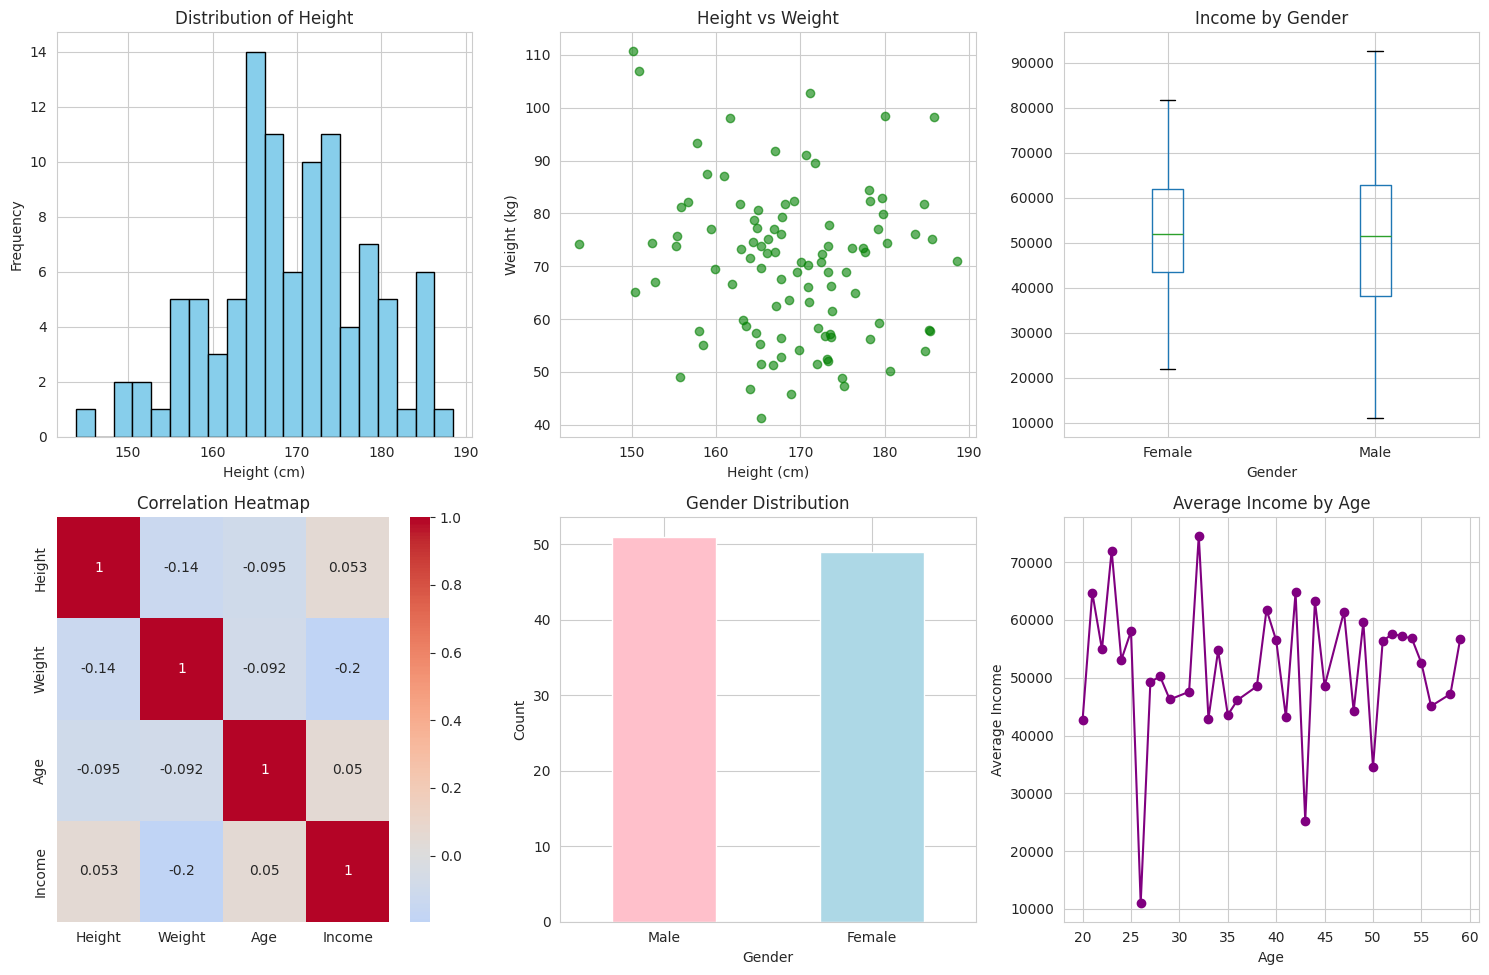

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "=" * 60)
print("PART 2: DATA VISUALIZATION")
print("=" * 60)

# Set style
sns.set_style("whitegrid")

# Create a more interesting dataset for visualization
np.random.seed(42)
viz_data = pd.DataFrame({
    'Height': np.random.normal(170, 10, 100),
    'Weight': np.random.normal(70, 15, 100),
    'Age': np.random.randint(20, 60, 100),
    'Income': np.random.normal(50000, 20000, 100),
    'Gender': np.random.choice(['Male', 'Female'], 100)
})



print("\nVisualization Dataset:")
print(viz_data.head())

# 1. Histogram
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.hist(viz_data['Height'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Height')
plt.xlabel('Height (cm)')
plt.ylabel('Frequency')

# 2. Scatter plot
plt.subplot(2, 3, 2)
plt.scatter(viz_data['Height'], viz_data['Weight'], alpha=0.6, color='green')
plt.title('Height vs Weight')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')

# 3. Box plot
plt.subplot(2, 3, 3)
viz_data.boxplot(column='Income', by='Gender', ax=plt.gca())
plt.title('Income by Gender')
plt.suptitle('')

# 4. Correlation heatmap
plt.subplot(2, 3, 4)
correlation = viz_data[['Height', 'Weight', 'Age', 'Income']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')

# 5. Count plot
plt.subplot(2, 3, 5)
viz_data['Gender'].value_counts().plot(kind='bar', color=['pink', 'lightblue'])
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)

# 6. Line plot (trend)
plt.subplot(2, 3, 6)
age_income = viz_data.groupby('Age')['Income'].mean().sort_index()
plt.plot(age_income.index, age_income.values, marker='o', color='purple')
plt.title('Average Income by Age')
plt.xlabel('Age')
plt.ylabel('Average Income')

plt.tight_layout()
print("\n✓ All visualizations created! (Check the plot window)")

## PREPROCESSING

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler

print("\n" + "=" * 60)
print("PART 3: DATA PREPROCESSING")
print("=" * 60)

# Create a sample dataset
prep_data = pd.DataFrame({
    'Age': [25, 30, 35, 40, 45, 28, 33, 38, 42, 29],
    'Salary': [50000, 60000, 75000, 80000, 90000, 55000, 65000, 78000, 85000, 58000],
    'Experience': [2, 5, 10, 15, 20, 3, 7, 12, 17, 4],
    'City': ['NYC', 'LA', 'Chicago', 'NYC', 'LA', 'Chicago', 'NYC', 'LA', 'Chicago', 'NYC'],
    'Purchased': [0, 0, 1, 1, 1, 0, 1, 1, 1, 0]  # Target variable
})

print("\n1. Original Dataset:")
print(prep_data.head())

# 1. Train-Test Split
print("\n2. TRAIN-TEST SPLIT:")
X = prep_data[['Age', 'Salary', 'Experience']]
y = prep_data['Purchased']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print(f"Why split? To evaluate model on unseen data!")

# 2. Feature Scaling - StandardScaler
print("\n3. FEATURE SCALING (StandardScaler):")
print("Before scaling:")
print(X_train.head())

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
print("\nAfter scaling (mean=0, std=1):")
print(X_train_scaled_df.head())

# 3. Feature Scaling - MinMaxScaler
print("\n4. FEATURE SCALING (MinMaxScaler):")
minmax_scaler = MinMaxScaler()
X_train_minmax = minmax_scaler.fit_transform(X_train)
X_train_minmax_df = pd.DataFrame(X_train_minmax, columns=X_train.columns)
print("After MinMax scaling (range 0-1):")
print(X_train_minmax_df.head())

# 4. Encoding Categorical Variables
print("\n5. ENCODING CATEGORICAL VARIABLES:")

# Label Encoding
print("\nLabel Encoding (for ordinal data):")
le = LabelEncoder()
city_encoded = le.fit_transform(prep_data['City'])
print(f"Original: {prep_data['City'].values}")
print(f"Encoded: {city_encoded}")
print(f"Mapping: {dict(zip(le.classes_, range(len(le.classes_))))}")

# One-Hot Encoding
print("\nOne-Hot Encoding (for nominal data):")

city_onehot = pd.get_dummies(prep_data['City'], prefix='City')
city_onehot = city_onehot.astype(int)

city_onehot.head()




PART 3: DATA PREPROCESSING

1. Original Dataset:
   Age  Salary  Experience     City  Purchased
0   25   50000           2      NYC          0
1   30   60000           5       LA          0
2   35   75000          10  Chicago          1
3   40   80000          15      NYC          1
4   45   90000          20       LA          1

2. TRAIN-TEST SPLIT:
Training set size: (7, 3)
Testing set size: (3, 3)
Why split? To evaluate model on unseen data!

3. FEATURE SCALING (StandardScaler):
Before scaling:
   Age  Salary  Experience
0   25   50000           2
7   38   78000          12
2   35   75000          10
9   29   58000           4
4   45   90000          20

After scaling (mean=0, std=1):
        Age    Salary  Experience
0 -1.598357 -1.625235   -1.371989
1  0.479507  0.556587    0.342997
2  0.000000  0.322821    0.000000
3 -0.959014 -1.001857   -1.028992
4  1.598357  1.491654    1.714986

4. FEATURE SCALING (MinMaxScaler):
After MinMax scaling (range 0-1):
    Age  Salary  Experience


,City_Chicago,City_LA,City_NYC
0,0,0,1
1,0,1,0
2,1,0,0
3,0,0,1
4,0,1,0


## FIRST ML MODEL - LINEAR REGRESSION


PART 4: YOUR FIRST ML MODEL - LINEAR REGRESSION

1. House Price Dataset:
   Size_sqft          Price
0       1360  215106.139736
1       1794  273787.422980
2       1630  257716.616505
3       1595  247249.889862
4       2138  253441.705495
5       2669  285726.130251
6        966   71192.335523
7       1738  278782.348789
8        830  124113.393936
9       1982  227680.834566

2. Data Split:
Training samples: 80
Testing samples: 20

3. Training Linear Regression Model...
✓ Model trained!

4. Model Parameters:
Slope (coefficient): 97.93
Intercept: 55099.78
Equation: Price = 55099.78 + 97.93 × Size

5. Making Predictions:
    Actual Price  Predicted Price    Difference
0  377979.470782    333514.263703  44465.207079
1  281284.253340    380618.508560 -99334.255220
2  208564.841935    172811.424178  35753.417757
3  306802.366459    320881.316537 -14078.950078
4  452486.681007    386886.017231  65600.663776

6. Model Evaluation:
Mean Absolute Error (MAE): $41,504.14
Root Mean Squared Err

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


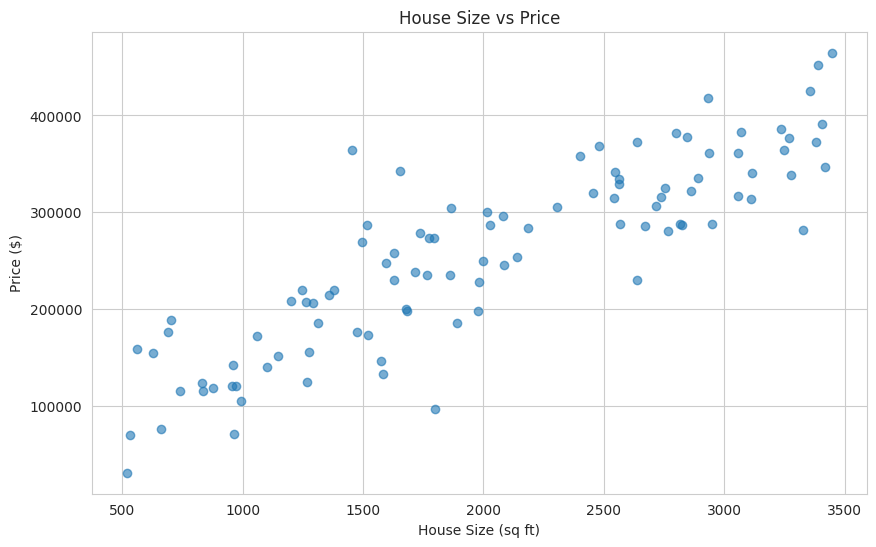

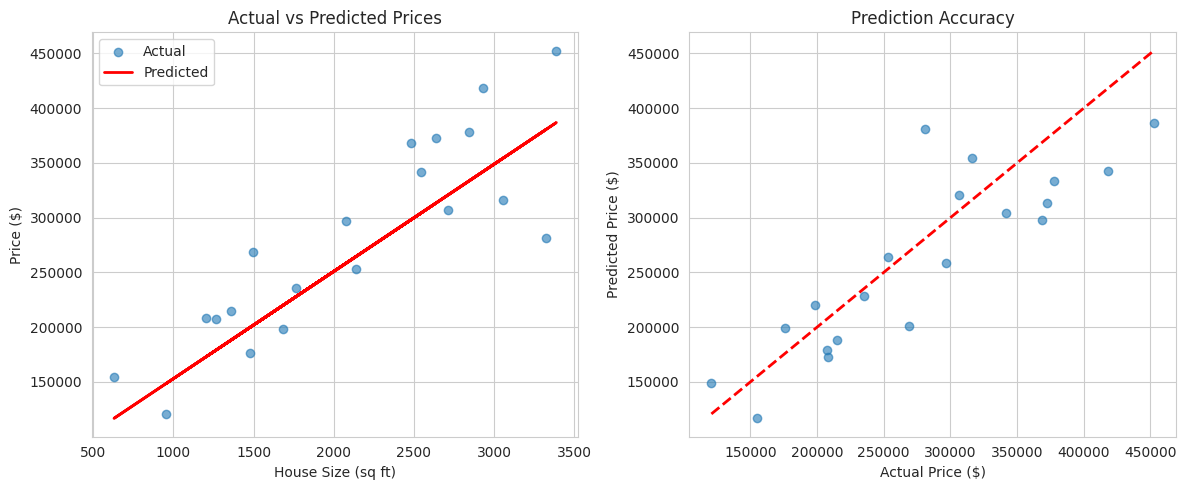

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("\n" + "=" * 60)
print("PART 4: YOUR FIRST ML MODEL - LINEAR REGRESSION")
print("=" * 60)

# Create a simple dataset: Predict House Price based on Size
np.random.seed(42)
house_size = np.random.randint(500, 3500, 100)
house_price = 50000 + 100 * house_size + np.random.normal(0, 50000, 100)

house_data = pd.DataFrame({
    'Size_sqft': house_size,
    'Price': house_price
})

print("\n1. House Price Dataset:")
print(house_data.head(10))

# Visualize the relationship
plt.figure(figsize=(10, 6))
plt.scatter(house_data['Size_sqft'], house_data['Price'], alpha=0.6)
plt.xlabel('House Size (sq ft)')
plt.ylabel('Price ($)')
plt.title('House Size vs Price')
plt.grid(True)

# Prepare data
X = house_data[['Size_sqft']]
y = house_data['Price']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n2. Data Split:")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# Create and train model
print("\n3. Training Linear Regression Model...")
model = LinearRegression()
model.fit(X_train, y_train)
print("✓ Model trained!")

# Model parameters
print(f"\n4. Model Parameters:")
print(f"Slope (coefficient): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")
print(f"Equation: Price = {model.intercept_:.2f} + {model.coef_[0]:.2f} × Size")

# Make predictions
print("\n5. Making Predictions:")
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    'Actual Price': y_test.values[:5],
    'Predicted Price': y_pred[:5],
    'Difference': y_test.values[:5] - y_pred[:5]
})
print(comparison)

# Evaluate model
print("\n6. Model Evaluation:")
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R² Score: {r2:.4f}")
print(f"\nInterpretation: Model explains {r2*100:.2f}% of price variance")

# Visualize predictions
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_test, y_test, alpha=0.6, label='Actual')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted')
plt.xlabel('House Size (sq ft)')
plt.ylabel('Price ($)')
plt.title('Actual vs Predicted Prices')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Prediction Accuracy')
plt.grid(True)

plt.tight_layout()

# Predict new value
print("\n7. Predict Price for New House:")
new_house_size = [[2000]]
predicted_price = model.predict(new_house_size)
print(f"For a house of 2000 sq ft, predicted price: ${predicted_price[0]:,.2f}")

plt.show()

